# To-dos (13/11/23)

1. Remove fits to log, only use fit_short
2. Investigate the bad fits for the slices 
3. Confirm that the mcmc really does work for the entire fit
4. Plot the curve using [a, b, c, d] and play around with these values
5. Fix d = 0.5, and add "error parameters" for the temperature (eT + f) 
6. Run mcmc for this starting from e = 1, f = 0
7. Just use the entire series as your fit function

In [2]:
import emcee as mc #try markov chain monte carlo

In [3]:
import numpy as np
import matplotlib.pyplot as plt
import data_analysis_script as da
import importlib as im
from scipy.optimize import curve_fit, minimize
import emcee as mc #try markov chain monte carlo

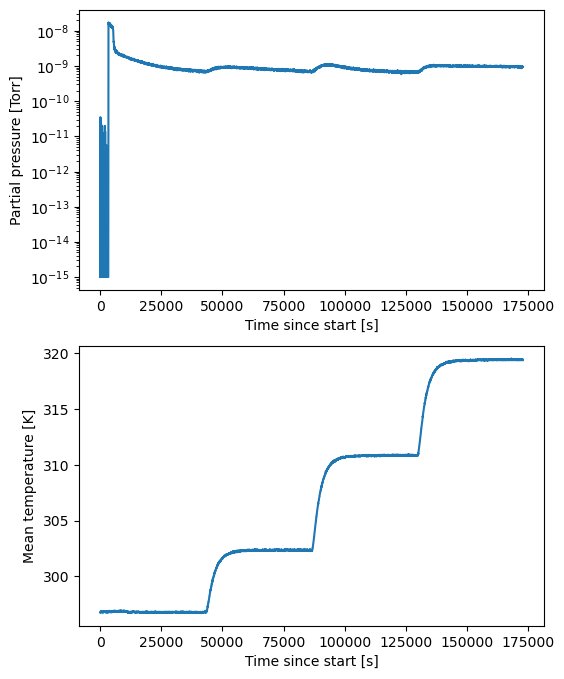

In [4]:
from data_analysis_script import Dataset
run_label = '2024-02-01' ## Change this to look at different runs
d = Dataset(run_label=run_label, gases=['O2'],data_path='20240201/')
d.GetData()
d.PlotSingleGas('O2')

In [5]:
time = np.array(d.data['O2']['Exposure_time'])
temp = np.array(d.data['O2']['Mean_temp']) #['Mean_temp'])
p = np.array(d.data['O2']['Partial_pressure'])

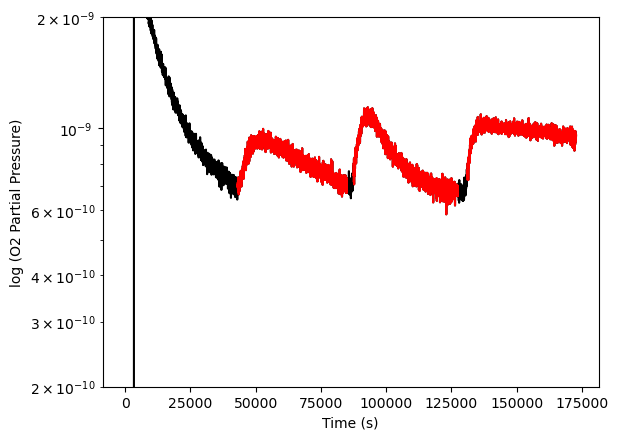

In [6]:
time_slices = [[43000, 85000],
               [87500, 127500],
               [131000, 175000]]

plt.semilogy(time, p, 'k') # Plot the logarithm (base 10) of the partial pressure of O2 (oxygen) against time. 
plt.ylabel('log (O2 Partial Pressure)') 
plt.xlabel('Time (s)')

for ts in time_slices:
    gpts = (time > ts[0]) & (time < ts[1])
    plt.semilogy(time[gpts], p[gpts],'r')
plt.ylim(2e-10, 2e-9)
#plt.xlim(12e4, 14e4)
plt.show()

# MCMC

In [9]:
def combined_chisq_short(params, data_list, y):
    ds = Dataset("","","")
    ndsets = len(data_list)

    a, b, c, d, e, f = params[0], params[1], params[2], params[3], params[4], params[5]


    tot_chisq = 0
    sig = 0.5e-9 ## error on values
    e_err = 0.1
    f_err = 1
    

    for n in range(ndsets):
        cdat = data_list[n]
        cy = y[n]
        curr_chisq = np.sum(((ds.fitfunction_offset(cdat, a, b, c, d, e, f) - cy)/sig)**2) +((e - 1)/(2*e_err))**2 + ((f - 0)/(2*f_err))**2
        if(not np.isnan(curr_chisq)):
            tot_chisq += curr_chisq
        else:
            tot_chisq += np.inf

    print(tot_chisq)
    return tot_chisq

time_slices = [[43000, 85000],
               [87500, 127500],
               [131000, 175000]]
tT = []
y = []
combined_data = []
for j,ts in enumerate(time_slices):
    gpts = (time > ts[0]) & (time < ts[1])
    tT.append((np.vstack((time[gpts], temp[gpts]))))
    y.append(p[gpts])
    combined_data.append([time[gpts], p[gpts]])

In [10]:
spars = np.array([5e-3, 6000, 0, 1, 0, 0])
print(combined_chisq_short(spars, tT, y))
res = minimize(combined_chisq_short, spars, args=(tT, y), method='Nelder-Mead', options={"maxiter": 10000})

12097.44177153876
12097.44177153876
12097.44177153876
12066.278678547798
12484.890400518105
12097.441884726397
11189.994396585673
12097.39476342277
12097.441771585636
10556.820003730165
6942.854560411707
10859.554911912724
10101.957122004522
8686.168569354633
5944.211126818806
1316.9066162563006
1131.9860999262633
213818.0017303152
2484.689597257025
27189.348287107918
8476.308971212642
16180.230177795518
7588.150085868775
4240.794448177415
35707.99963004925
5321.12872728187
29902.95648420646
4503.369921201405
25942.485492653108
3855.4890705794855
14692.180494137601
2888.229573453119
12412.951205679617
2381.0586631492624
4468.124583369939
1270.2834641413563
7408.4731637248515
2114.040137306726
4815.297505663276
1687.3945391974632
2948.236317988145
1179.9629405705357
2948.4160484776357
1523.7415247403828
2815.412829809964
1393.1786174654815
2135.2980847368367
1241.9741616045096
2039.554004738985
1178.7471138167934
1945.82670846013
1133.2880057872133
1279.8189841818769
1129.1443632208184


426.3768424100124
453.0321960416586
421.13434123986065
406.8292114231695
400.54399936952933
412.04014360306843
401.3829257281838
397.1972783205122
409.27702787434305
403.9271201172112
400.7175095555435
390.00209648611076
396.0140418940428
384.32638326456964
374.195102047815
407.87679954815405
394.19287864699146
382.9913996117847
396.4004531427011
431.3822216364512
391.2816948882827
375.1814700344308
393.8192116246121
374.80968103606875
388.2192370803137
384.4924986524537
366.7433368828594
378.9464692831793
373.7068617730273
389.0848772940035
372.1865586827872
359.9333187854566
350.5259462217651
358.70115212968204
356.49082989782795
355.05996230304686
391.01921755353095
363.133570213516
342.53502191608766
331.18241900797227
346.0846134028469
338.8188528810765
348.9668242300532
324.8314298104744
320.3591671969355
317.9526724746104
306.131401794908
361.4101971837037
336.83332021281086
352.2525700729342
330.63967052648724
353.938087287647
332.9541667198399
323.89398174373633
308.1770587430

225.30770437822508
225.35839306635606
225.3346213586483
225.3514633549242
225.41334350272774
225.33336431265067
225.3537175598472
225.33257822312274
225.3064210237778
225.29351263949545
225.30896979920027
225.28754417946453
225.27559900537435
225.3310258782795
225.2788948753302
225.25792772314986
225.23272192314633
225.30238047879496
225.35068975582396
225.28590444603765
225.3863898311614
225.2838279186281
225.31109101150378
225.27430113876792
225.2435106969695
225.27953242882484
225.35325717594085
225.26544306530747
225.2793919847948
225.26608574881953
225.25362481151012
225.25511882295993
225.25259267958694
225.22865668443447
225.220908006556
225.2224016550285
225.21595300450957
225.22145582621778
225.22198644962168
225.29116322826548
225.23010420129282
225.23696232366706
225.21577617850147
225.22124041253196
225.31860404475407
225.21663751302233
225.21051004387135
225.21580931569775
225.21528168379808
225.22813065438856
225.21114610113125
225.2060576778433
225.20787998826034
225.211

In [11]:
print(res.x)

[5.20162957e-07 1.12215004e+03 7.18969627e-04 5.80869948e-01
 5.66802011e-03 1.01856533e-03]


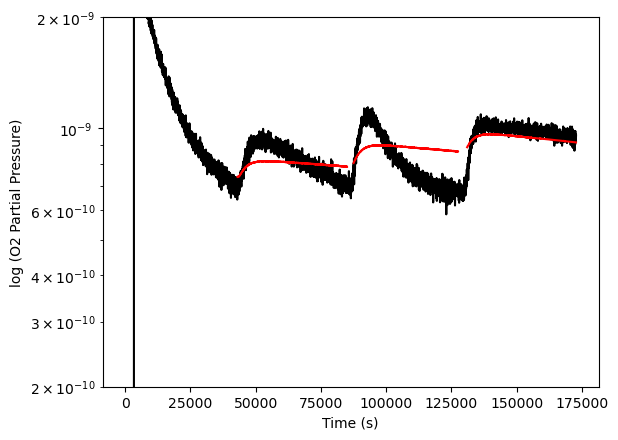

In [12]:
plt.figure()
plt.semilogy(time, p, 'k') # Plot the logarithm (base 10) of the partial pressure of O2 (oxygen) against time. 
for i in range(len(combined_data)):
    plt.plot(combined_data[i][0], np.abs(d.fitfunction_offset(tT[i], *res.x)), 'r')
plt.ylabel('log (O2 Partial Pressure)') 
plt.xlabel('Time (s)')

plt.ylim(2e-10, 2e-9)

plt.show()

In [13]:
print(res.x)

[5.20162957e-07 1.12215004e+03 7.18969627e-04 5.80869948e-01
 5.66802011e-03 1.01856533e-03]


/gpfs/gibbs/project/david_moore/rjt45/outgassing-setup/analysis/data_analysis_script.py:35: RuntimeWarning: overflow encountered in exp
  factor = np.exp(-1.0*b/tT[1])
/gpfs/gibbs/project/david_moore/rjt45/outgassing-setup/analysis/data_analysis_script.py:36: RuntimeWarning: overflow encountered in exp
  return a * factor * np.exp(-1.0*c*tT[0]*factor)
/gpfs/gibbs/project/david_moore/rjt45/outgassing-setup/analysis/data_analysis_script.py:36: RuntimeWarning: invalid value encountered in multiply
  return a * factor * np.exp(-1.0*c*tT[0]*factor)


bp: [8.70015459e+04 9.57999634e+03 5.20272861e+08]
bp: [4.20190818e+17 1.86419504e+04 1.58811788e+21]
bp: [1.02308267e+00 6.48061032e+03 1.96079675e+03]


IndexError: index 3 is out of bounds for axis 0 with size 3

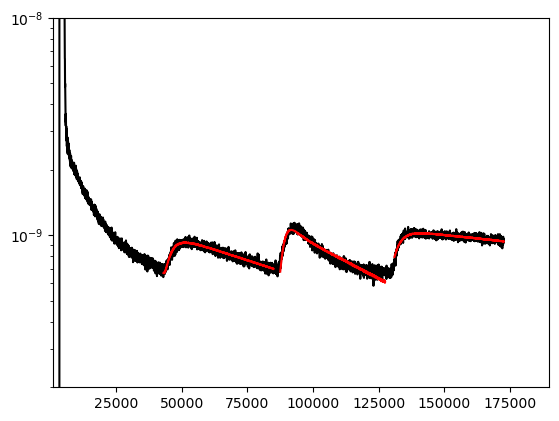

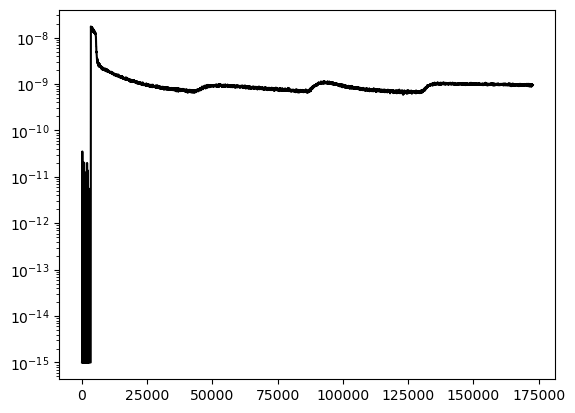

In [14]:
#Plotting Code

time_slices = [[43000, 85000],
               [87500, 127500],
               [131000, 175000]]

#Plot with different fit parameters for each time slice

plt.figure()
plt.semilogy(time, p, 'k')

for j,ts in enumerate(time_slices):
    gpts = (time > ts[0]) & (time < ts[1])
    tT = np.vstack((time[gpts], temp[gpts]))
    y = p[gpts]
    spars = [1.29648471e-01, 7.99649264e+03, -1.11283810e-01]
    #spars = [3.48859880e-09, -3.45969798e+01, 3.98032858e-01, 1, 0]
    #Spars that work for curvefit: 3.48859880e-09, -3.45969798e+01, 3.98032858e-01, 1, 0
    #Spars from old teflon data: 3.48859880e-09, 3.45969798e+03, 3.98032858e-01, 1, 0
    #res = minimize(combined_chisq_short, spars, args=(combined_data), method='Nelder-Mead')
    #bp = res.x
    bp, bc = curve_fit(d.fitfunction, tT, y, p0=spars, method='lm', maxfev=90000)
    plt.plot(tT[0], d.fitfunction(tT,*bp),'r')
    print('bp:', bp)
    plt.ylim(2e-10, 1e-8)
    plt.xlim(1e3, 19e4)
    #res = minimize(combined_chisq_short, spars, args=(combined_data,))
    #bp = res.x

#Plot with the same fit parameters for all time slices
tT = []
y = []
combined_data = []
plt.figure()
plt.semilogy(time, p, 'k')
for j,ts in enumerate(time_slices):
    gpts = (time > ts[0]) & (time < ts[1])
    tT.append((np.vstack((time[gpts], temp[gpts]))))
    y.append(p[gpts])
    combined_data.append([time[gpts], p[gpts]])
spars = [1.29648471e-01, 7.99649264e+03, -1.11283810e-01]
#spars = [7.08859880e-05, 3.45969798e+03, 1.28032858e+03, 1, 5]
#bp, bc = curve_fit(d.fitfunction_short_temp_offset, np.vstack((time,temp)), p, p0=spars, method='lm', maxfev=90000)
res = minimize(combined_chisq_short, spars, args=(tT, y))
bp = res.x

for j in range(len(time_slices)):
    tvals = combined_data[j][0]
    plt.plot(tvals, d.fitfunction(tT[j], *bp), 'r')
    

print('bp:', bp)

plt.ylabel('Pressure [mbar]')
plt.xlabel("Time [s]")
plt.ylim(2e-10, 1e-8)
plt.xlim(1e3, 19e4)


In [ ]:
tvec = np.logspace(-6,0,1000)

maxn = 200

fval = np.zeros_like(tvec)
for n in range(maxn):
    fval += np.exp(-(np.pi*(2*n+1))**2*tvec)

plt.figure()
plt.loglog(tvec, fval)

In [ ]:
nwalkers, ndim = 100, 3

ffn = lambda p,d,y: -combined_chisq_short(p,d, y)

scaling_factors = np.array([1e-1, 7e+3, 1e-1])
p0 = [spars + scaling_factors*0.001*np.random.randn(ndim) for i in range(nwalkers)]

sampler = mc.EnsembleSampler(nwalkers, ndim, ffn, args=(tT,y))
sampler.run_mcmc(p0, 4000, progress=True)

In [ ]:
# Extract the chain of samples
samples = sampler.get_chain()

# Calculate the median of each parameter across all walkers and steps
median_params = np.median(samples, axis=(0, 1))

# Print the median parameters
print("Median parameters:", median_params)
print('P0:', p0)

In [ ]:
fig, axes = plt.subplots(5, figsize=(10, 7), sharex=True)
samples = sampler.get_chain()
labels = ["a", "b", "c", "e","f"]
for i in range(ndim):
    ax = axes[i]
    ax.plot(samples[:, :, i], "k", alpha=0.3)
    ax.set_xlim(0, len(samples))
    ax.set_ylabel(labels[i])
    ax.yaxis.set_label_coords(-0.1, 0.5)

axes[-1].set_xlabel("step number");

In [ ]:
import corner

flat_samples = sampler.get_chain(discard=1000, thin=15, flat=True)
print(flat_samples.shape)

fig = corner.corner(flat_samples, labels=labels)

In [ ]:
plt.figure()
plt.semilogy(time, p, 'k')
tT_final = []
for j,ts in enumerate(time_slices):
    gpts = (time > ts[0]) & (time < ts[1])
    tT_final.append((np.vstack((time[gpts],temp[gpts]))))
inds = np.random.randint(len(flat_samples), size=10)
for ind in inds:
    sample = flat_samples[ind]
    for j in range(len(time_slices)):
        tvals = combined_data[j][0]
        plt.plot(tvals, d.fitfunction_short_temp_offset(tT_final[j], sample[0], sample[1], sample[2], sample[3], sample[4]), 'r', alpha=0.5)

plt.ylim(6e-10, 6e-9)
plt.ylabel('Pressure [mbar]')
plt.xlabel("Time [s]")

In [ ]:
from IPython.display import display, Math

CI = 10 ## L/s
Area = 0.01 ## m^2
mbar_to_Pa = 100
K = 0.22
p_atm = 1.01e5 #Pa
m_to_cm = 100
L_to_m3 = 1e-3

mcmc_D0 = np.percentile((flat_samples[:, 0]*CI*mbar_to_Pa*L_to_m3/(K*p_atm*Area) * m_to_cm)**2, [16, 50, 84])
mcmc_Ea = np.percentile(flat_samples[:, 1], [16, 50, 84])

print("D0 [cm^2/s]: ", mcmc_D0)
print("Activation energy [K]: ", mcmc_Ea)